<a href="https://colab.research.google.com/github/SubodhWalondre-1/Machine-Vision-Lab/blob/main/Prac_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving man.jpg to man.jpg


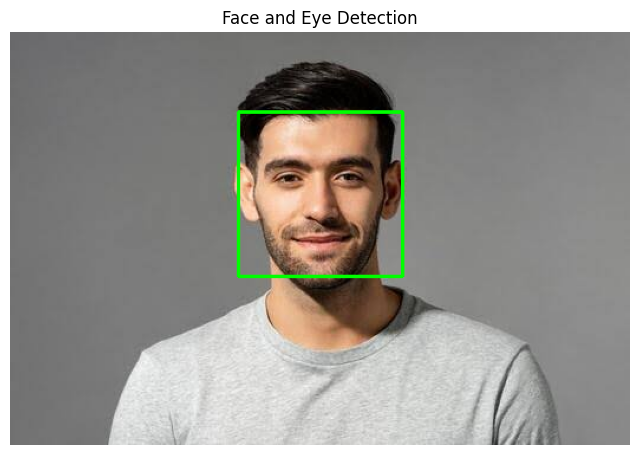

========== Detection Report ==========
Faces Detected : 1
Eyes Detected  : 0
Estimated Detection Accuracy : 0.00%

Lighting Analysis
---------------------------
Average Brightness : 137.4
Lighting Condition : Normal Light


In [1]:
# ==========================================
# Face and Eye Detection using Haar Cascades
# ==========================================

# Install/OpenCV (if needed)
!pip -q install opencv-python-headless matplotlib

import cv2
import matplotlib.pyplot as plt
from google.colab import files

# Upload Image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Read Image
img = cv2.imread(image_path)
original = img.copy()

# Convert to Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -------------------------------
# Lighting Enhancement
# -------------------------------
equalized = cv2.equalizeHist(gray)

# Haar Cascade Classifiers
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_eye.xml'
)

# Detect Faces
faces = face_cascade.detectMultiScale(
    equalized,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(40,40)
)

face_count = len(faces)
eye_count = 0

# Draw Face and Eye Rectangles
for (x,y,w,h) in faces:

    cv2.rectangle(original,(x,y),(x+w,y+h),(0,255,0),2)

    roi_gray = equalized[y:y+h, x:x+w]
    roi_color = original[y:y+h, x:x+w]

    eyes = eye_cascade.detectMultiScale(
        roi_gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(20,20)
    )

    eye_count += len(eyes)

    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(
            roi_color,
            (ex,ey),
            (ex+ew,ey+eh),
            (255,0,0),
            2
        )

# Display Result
plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title("Face and Eye Detection")
plt.axis("off")
plt.show()

# -------------------------------
# Simple Detection Accuracy
# -------------------------------
print("========== Detection Report ==========")
print("Faces Detected :", face_count)
print("Eyes Detected  :", eye_count)

if face_count > 0:
    accuracy = min((eye_count/(face_count*2))*100,100)
else:
    accuracy = 0

print(f"Estimated Detection Accuracy : {accuracy:.2f}%")

# Lighting Condition Evaluation
brightness = gray.mean()

print("\nLighting Analysis")
print("---------------------------")
print("Average Brightness :", round(brightness,2))

if brightness < 70:
    print("Lighting Condition : Low Light")
elif brightness < 150:
    print("Lighting Condition : Normal Light")
else:
    print("Lighting Condition : Bright Light")